In [1]:
!pip install faiss-gpu-cu12 h5py pandas matplotlib seaborn psutil scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 9.3 MB/s eta 0:00:00


-------
### 1. Imports and Configuration

-------

In [2]:
import os, gc, time, h5py, faiss, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Setup for report images
IMG_DIR = "ieee_report_images"
os.makedirs(IMG_DIR, exist_ok=True)

def save_plot(filename):
    plt.savefig(f"{IMG_DIR}/{filename}.png", dpi=300, bbox_inches='tight')
    print(f"Figure saved: {IMG_DIR}/{filename}.png")

sns.set_theme(style="whitegrid")
print("Environment Ready. FAISS Version:", faiss.__version__)

Environment Ready. FAISS Version: 1.14.1


-------
### 2. Data Loading & Augmentation

-------

In [3]:
from google.colab import drive
drive.mount('/content/drive')

def augment_data(base_vectors, target_count):
    """Tiles data and adds Gaussian noise to reach target_count (Scientific Scaling)."""
    current_count = base_vectors.shape[0]
    if current_count >= target_count:
        return base_vectors[:target_count]

    repeats = int(np.ceil(target_count / current_count))
    augmented = np.tile(base_vectors, (repeats, 1))[:target_count]


    noise = np.random.normal(0, 0.005, augmented.shape).astype('float32')
    return augmented + noise

def load_hdf5_dataset(filepath, name, target_scale):
    print(f"Loading {name} for {target_scale} scale...")
    with h5py.File(filepath, 'r') as f:
        queries = np.array(f['test']).astype('float32')
        ground_truth = np.array(f['neighbors'])[:, :10]
        base = np.array(f['train']).astype('float32')


    count = 100000 if target_scale == "100k" else 1000000
    base = augment_data(base, count)

    if "DEEP" in name.upper():
        print("Normalizing Deep-Image (Angular -> L2)...")
        faiss.normalize_L2(base)
        faiss.normalize_L2(queries)

    return base, queries, ground_truth

def calculate_recalls(predictions, ground_truth):
    r1 = np.mean([1 if p[0] == t[0] else 0 for p, t in zip(predictions, ground_truth)])
    rk = []
    for p, t in zip(predictions, ground_truth):
        rk.append(len(set(p[:10]).intersection(set(t[:10]))) / 10.0)
    return r1, np.mean(rk)

Mounted at /content/drive


-------
### 3. Benchmarking Engine

-------

In [4]:
def run_benchmarks(base, queries, gt, ds_name, scale):
    d = base.shape[1]
    res = faiss.StandardGpuResources()
    results = []

    def log_metric(idx, name, p_name="-", p_val="-", b_t=0.0):
        # Memory tracking (RSS)
        mem = psutil.Process(os.getpid()).memory_info().rss / (1024*1024)

        # Batch Search for QPS
        st = time.perf_counter()
        dist, ids = idx.search(queries, 10)
        et = time.perf_counter() - st

        qps = len(queries) / et
        r1, r10 = calculate_recalls(ids, gt)

        results.append({
            'Dataset': ds_name, 'Scale': scale, 'Method': name,
            'Param': p_name, 'Param_Val': p_val, 'Build Time (s)': b_t,
            'Mem (MB)': mem, 'QPS': qps, 'Recall@1': r1, 'Recall@10': r10
        })

    nlist = int(np.sqrt(base.shape[0]))

    # 1. FlatL2
    idx = faiss.index_cpu_to_gpu(res, 0, faiss.IndexFlatL2(d))
    t0 = time.perf_counter(); idx.add(base); bt = time.perf_counter()-t0
    log_metric(idx, 'FlatL2', b_t=bt); del idx; gc.collect()

    # 2. IVFFlat
    ivf = faiss.IndexIVFFlat(faiss.IndexFlatL2(d), d, nlist)
    idx = faiss.index_cpu_to_gpu(res, 0, ivf)
    t0 = time.perf_counter(); idx.train(base); idx.add(base); bt = time.perf_counter()-t0
    idx.nprobe = 10; log_metric(idx, 'IVFFlat', 'nprobe', 10, bt); del idx; gc.collect()

    # 3. IVFPQ
    pq = faiss.IndexIVFPQ(faiss.IndexFlatL2(d), d, nlist, 8, 8)
    idx = faiss.index_cpu_to_gpu(res, 0, pq)
    t0 = time.perf_counter(); idx.train(base); idx.add(base); bt = time.perf_counter()-t0
    for np_val in [1, 10, 50]:
        idx.nprobe = np_val
        log_metric(idx, 'IVFPQ', 'nprobe', np_val, bt)
    del idx; gc.collect()

    # 4. IVFSQ (Bonus: Scalar Quantization)
    sq = faiss.IndexIVFScalarQuantizer(faiss.IndexFlatL2(d), d, nlist, faiss.ScalarQuantizer.QT_8bit)
    idx = faiss.index_cpu_to_gpu(res, 0, sq)
    t0 = time.perf_counter(); idx.train(base); idx.add(base); bt = time.perf_counter()-t0
    idx.nprobe = 10; log_metric(idx, 'IVFSQ', 'nprobe', 10, bt); del idx; gc.collect()

    # 5. IVFOPQ (Bonus: Optimized PQ)
    opq = faiss.IndexPreTransform(faiss.OPQMatrix(d, 8), faiss.IndexIVFPQ(faiss.IndexFlatL2(d), d, nlist, 8, 8))
    t0 = time.perf_counter(); opq.train(base); opq.add(base); bt = time.perf_counter()-t0
    idx = faiss.index_cpu_to_gpu(res, 0, opq)
    faiss.downcast_index(idx.index).nprobe = 10
    log_metric(idx, 'IVFOPQ', 'nprobe', 10, bt); del idx; gc.collect()

    # 6. HNSW
    hnsw = faiss.IndexHNSWFlat(d, 32)
    t0 = time.perf_counter(); hnsw.add(base); bt = time.perf_counter()-t0
    hnsw.hnsw.efSearch = 64; log_metric(hnsw, 'HNSW', 'efSearch', 64, bt); del hnsw; gc.collect()

    # 7. LSH
    lsh = faiss.IndexLSH(d, 256)
    t0 = time.perf_counter(); lsh.train(base); lsh.add(base); bt = time.perf_counter()-t0
    log_metric(lsh, 'LSH', b_t=bt); del lsh; gc.collect()

    return pd.DataFrame(results)

-------
### 4. Execution Pipeline
-------

In [5]:
# UPDATE THESE PATHS
paths = {
    "GIST": "/content/drive/MyDrive/Tanvir/CSE488-FAISS-assignment/dataset/gist-960-euclidean.hdf",
    "DEEP": "/content/drive/MyDrive/Tanvir/CSE488-FAISS-assignment/dataset/deep-image-96-angular.hdf"
}

all_dfs = []
for name, path in paths.items():
    for scale in ["100k", "1M"]:
        base, q, gt = load_hdf5_dataset(path, name, scale)
        res_df = run_benchmarks(base, q, gt, name, scale)
        all_dfs.append(res_df)
        del base, q, gt; gc.collect()

final_df = pd.concat(all_dfs, ignore_index=True)
final_df.to_csv("benchmark_results.csv", index=False)
display(final_df)

Loading GIST for 100k scale...
Loading GIST for 1M scale...
Loading DEEP for 100k scale...
Normalizing Deep-Image (Angular -> L2)...
Loading DEEP for 1M scale...
Normalizing Deep-Image (Angular -> L2)...


,Dataset,Scale,Method,Param,Param_Val,Build Time (s),Mem (MB),QPS,Recall@1,Recall@10
0,GIST,100k,FlatL2,-,-,0.104360,4446.441406,6.756785e+03,0.0810,0.10340
1,GIST,100k,IVFFlat,nprobe,10,1.717643,4491.996094,1.350355e+04,0.0740,0.08780
2,GIST,100k,IVFPQ,nprobe,1,6.236742,4504.421875,9.478973e+03,0.0110,0.02270
3,GIST,100k,IVFPQ,nprobe,10,6.236742,4548.093750,1.540703e+05,0.0150,0.03370
4,GIST,100k,IVFPQ,nprobe,50,6.236742,4548.093750,3.808888e+04,0.0150,0.03380
5,GIST,100k,IVFSQ,nprobe,10,2.303153,4550.152344,1.940111e+04,0.0740,0.08780
6,GIST,100k,IVFOPQ,nprobe,10,743.016325,4624.257812,2.599396e+04,0.0220,0.05400
7,GIST,100k,HNSW,efSearch,64,562.570174,4990.949219,1.023906e+03,0.0800,0.09960
8,GIST,100k,LSH,-,-,0.912931,4624.980469,5.707879e+02,0.0050,0.01130
9,GIST,1M,FlatL2,-,-,0.858492,4614.328125,1.608361e+03,0.9900,0.99910


/tmp/ipykernel_6253/2591907036.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=quant_data, x='Method', y='Recall@10', ax=ax1, palette='viridis', alpha=0.8)


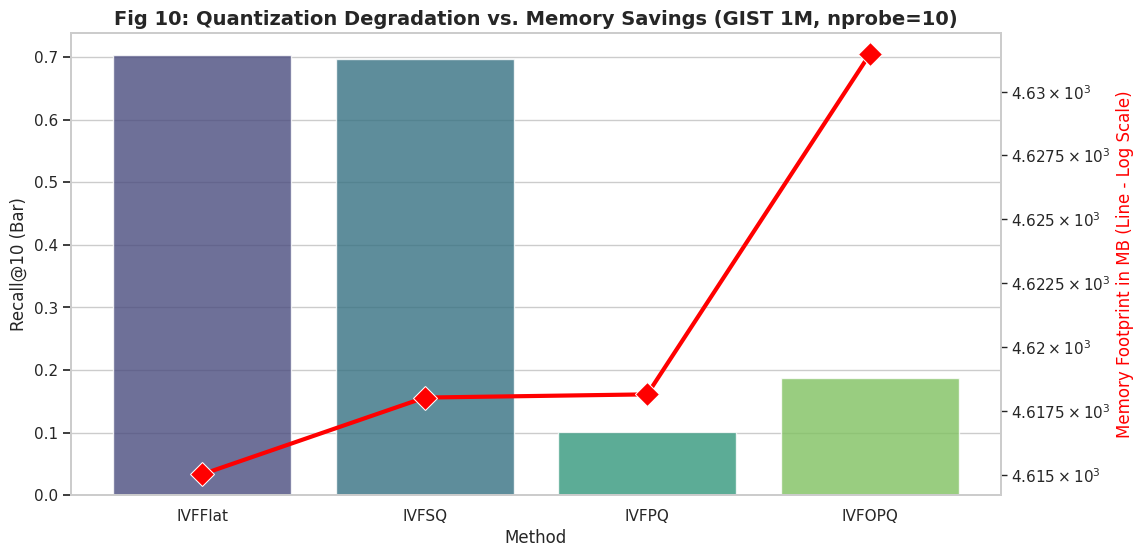

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('benchmark_results.csv')

# --- PLOT 3: The Quantization Degradation Step-Chart ---
quant_methods = ['IVFFlat', 'IVFSQ', 'IVFPQ', 'IVFOPQ']
quant_data = df[(df['Dataset'] == 'GIST') & (df['Scale'] == '1M') & (df['Method'].isin(quant_methods)) & (df['Param_Val'].astype(str) == '10')].copy()

# Ensure standard ordering for the plot
quant_data['Method'] = pd.Categorical(quant_data['Method'], categories=quant_methods, ordered=True)
quant_data = quant_data.sort_values('Method')

# Draw the Graph
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

sns.barplot(data=quant_data, x='Method', y='Recall@10', ax=ax1, palette='viridis', alpha=0.8)
sns.lineplot(data=quant_data, x='Method', y='Mem (MB)', ax=ax2, color='red', marker='D', markersize=12, linewidth=3)

ax1.set_ylabel('Recall@10 (Bar)', fontsize=12)
ax2.set_ylabel('Memory Footprint in MB (Line - Log Scale)', color='red', fontsize=12)
ax2.set_yscale('log')
plt.title("Fig 10: Quantization Degradation vs. Memory Savings (GIST 1M, nprobe=10)", fontsize=14, fontweight='bold')

plt.show()

-------
### 5. Visualization
-------

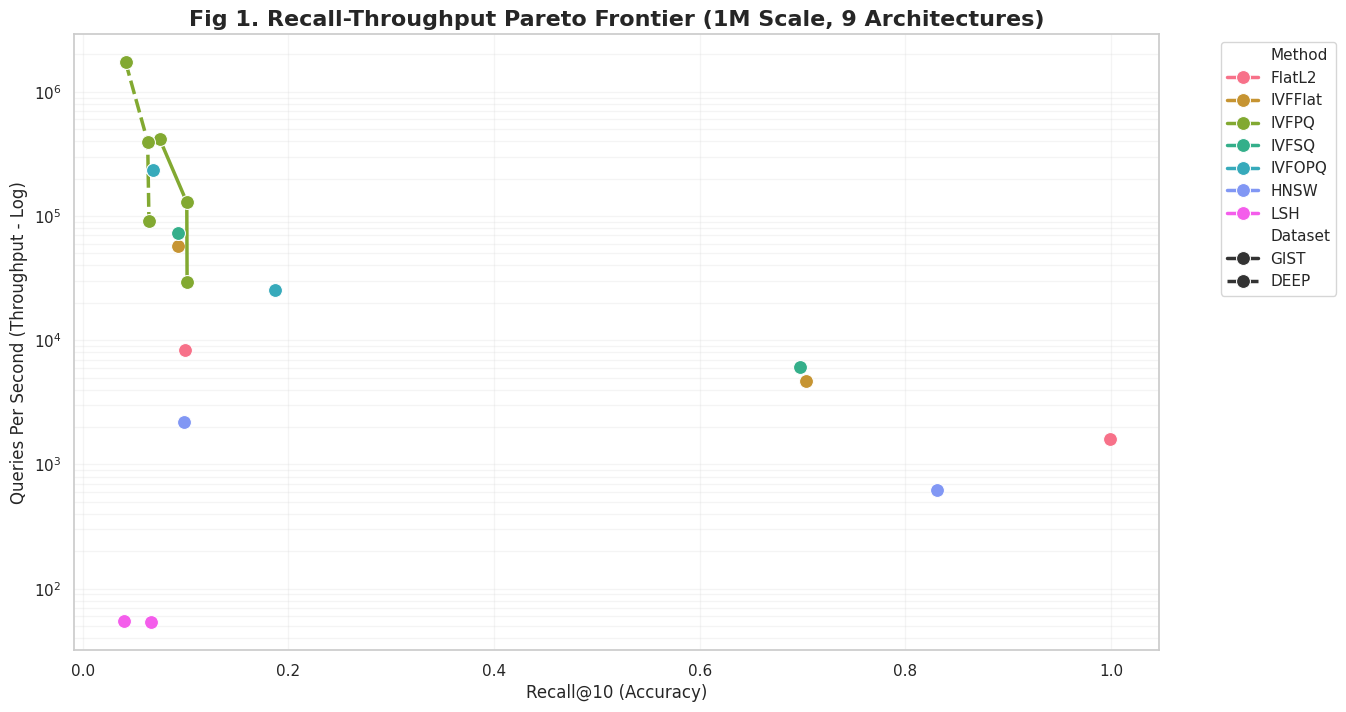

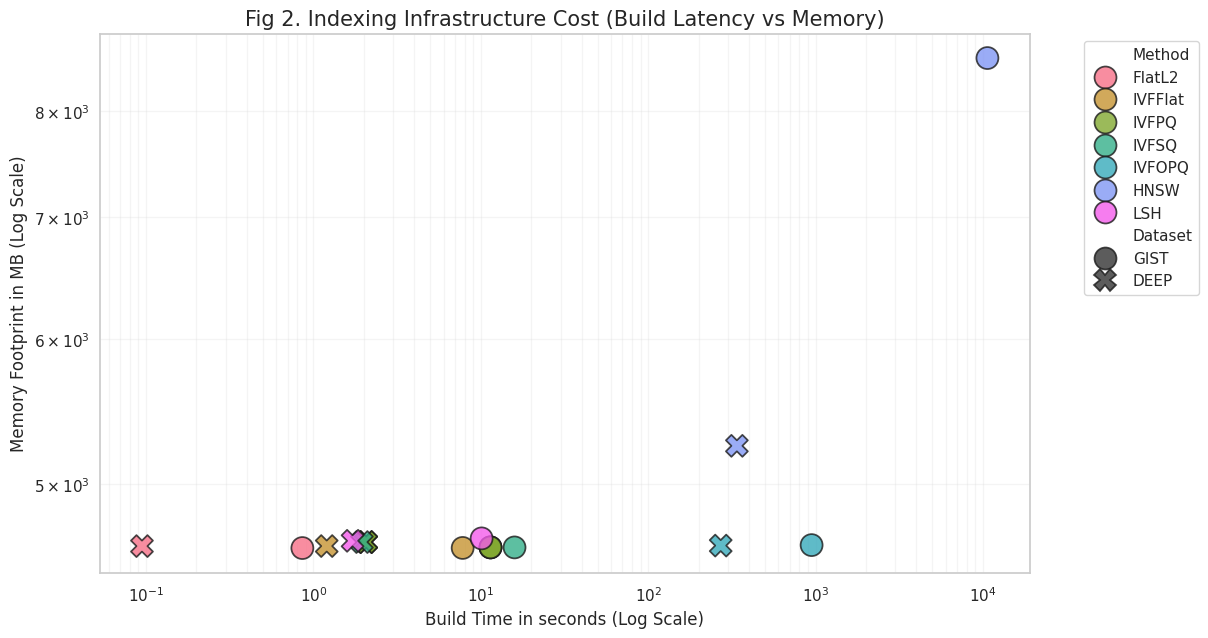

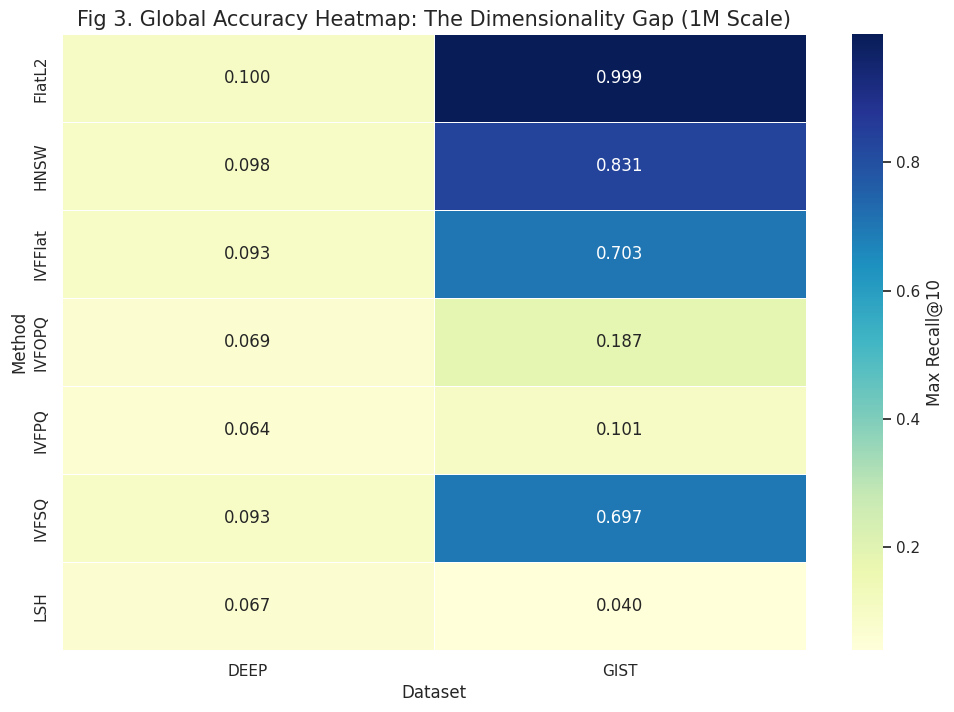

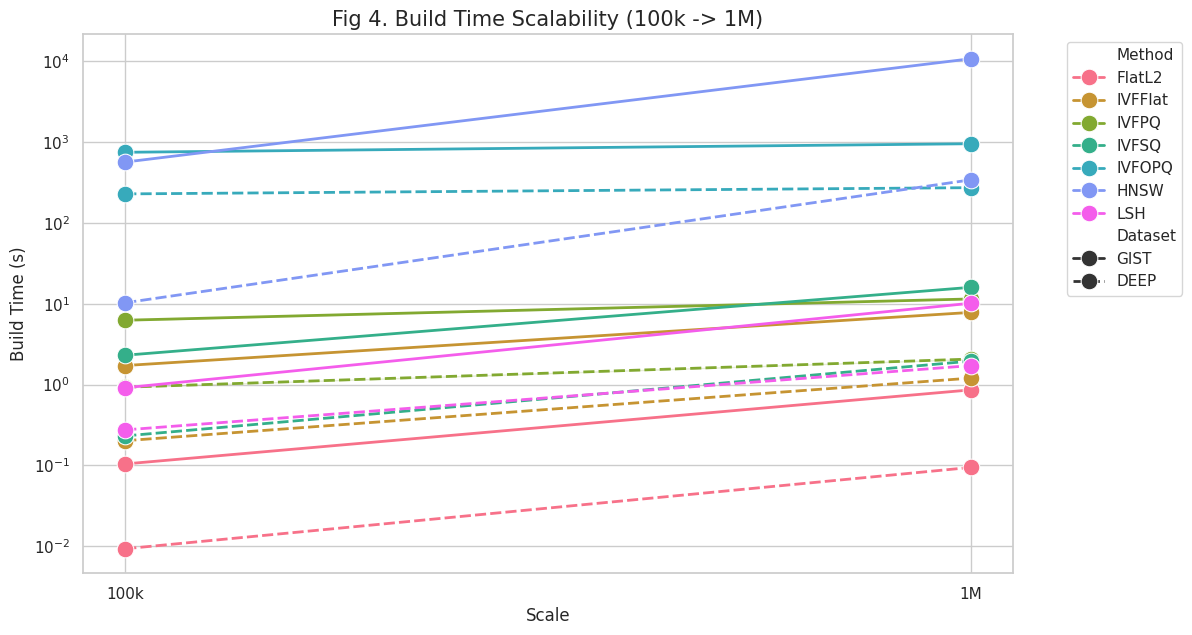

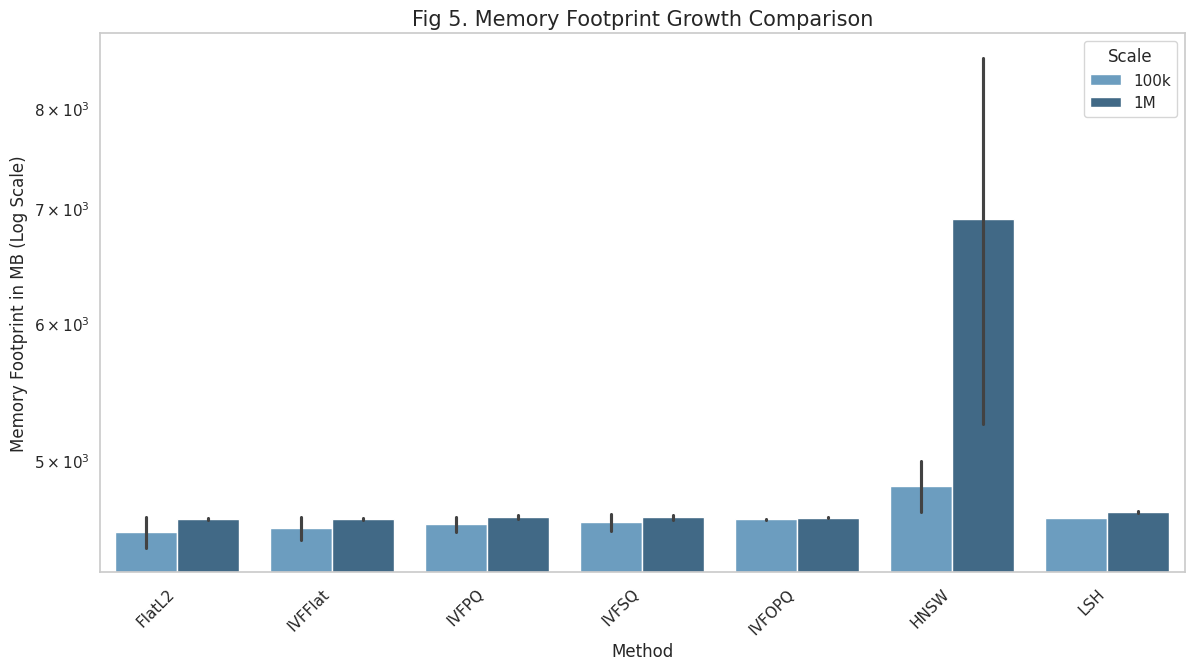

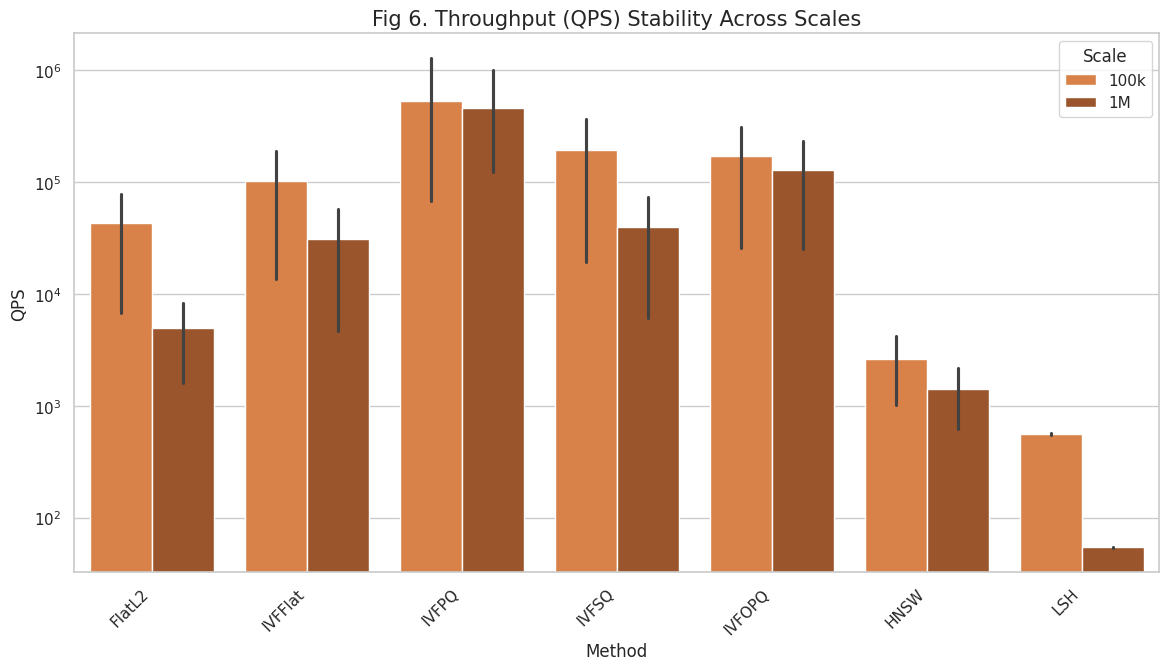

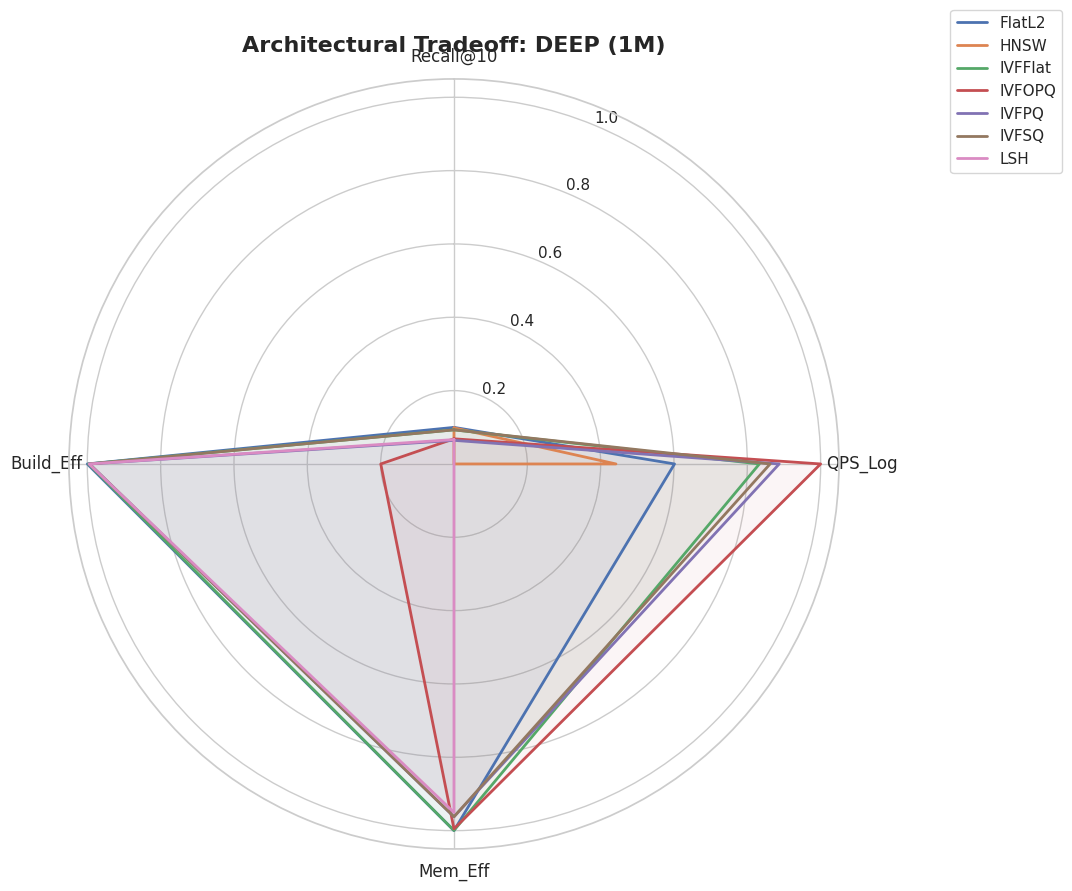

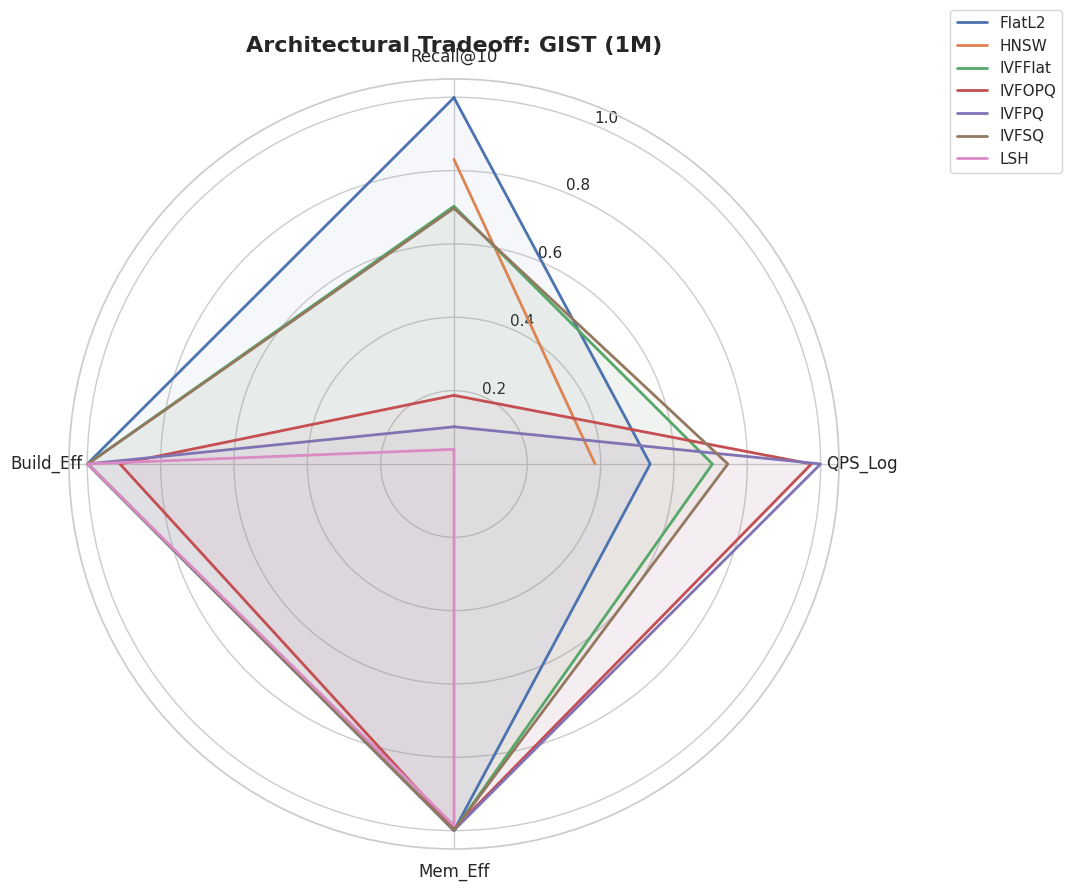

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Success! Downloaded 8 PNGs and 1 CSV for the LaTeX report.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os
import shutil
from google.colab import files

# 1. Load Data
df = pd.read_csv('/content/benchmark_results.csv')

# 2. Setup Directories
REPORT_DIR = "ieee_9method_visuals"
if os.path.exists(REPORT_DIR):
    shutil.rmtree(REPORT_DIR)
os.makedirs(REPORT_DIR)

def save_and_show(filename):
    plt.savefig(f"{REPORT_DIR}/{filename}.png", dpi=300, bbox_inches='tight')
    plt.show()

# Ensure we have enough colors for 9 methods
method_colors = sns.color_palette("husl", len(df['Method'].unique()))

# --- 1. The Efficiency Frontier (Recall vs QPS) ---
plt.figure(figsize=(14, 8))
sns.lineplot(data=df[df['Scale'] == '1M'], x='Recall@10', y='QPS',
             hue='Method', style='Dataset', marker='o', markersize=10, lw=2.5, palette=method_colors)
plt.yscale('log')
plt.title("Fig 1. Recall-Throughput Pareto Frontier (1M Scale, 9 Architectures)", fontsize=16, fontweight='bold')
plt.xlabel("Recall@10 (Accuracy)", fontsize=12)
plt.ylabel("Queries Per Second (Throughput - Log)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
save_and_show("efficiency_frontier")

# --- 2. Infrastructure Cost (Log-Log) ---
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df[df['Scale'] == '1M'], x='Build Time (s)', y='Mem (MB)',
                hue='Method', style='Dataset', s=250, alpha=0.8, edgecolor='k', palette=method_colors)
plt.xscale('log'); plt.yscale('log')
plt.title("Fig 2. Indexing Infrastructure Cost (Build Latency vs Memory)", fontsize=15)
plt.xlabel("Build Time in seconds (Log Scale)")
plt.ylabel("Memory Footprint in MB (Log Scale)")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
save_and_show("infrastructure_cost_analysis")

# --- 3. Global Accuracy Heatmap ---
plt.figure(figsize=(12, 8))
pivot = df[df['Scale'] == '1M'].pivot_table(index='Method', columns='Dataset', values='Recall@10', aggfunc='max')
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=.5, cbar_kws={'label': 'Max Recall@10'})
plt.title("Fig 3. Global Accuracy Heatmap: The Dimensionality Gap (1M Scale)", fontsize=15)
save_and_show("accuracy_heatmap")

# --- 4. Build Time Scaling (Complexity) ---
plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x='Scale', y='Build Time (s)', hue='Method', style='Dataset',
             marker='o', markersize=12, palette=method_colors, lw=2)
plt.yscale('log')
plt.title("Fig 4. Build Time Scalability (100k -> 1M)", fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
save_and_show("build_time_scaling")

# --- 5. Memory Growth Comparison ---
plt.figure(figsize=(14, 7))
sns.barplot(data=df, x='Method', y='Mem (MB)', hue='Scale', palette="Blues_d")
plt.title("Fig 5. Memory Footprint Growth Comparison", fontsize=15)
plt.yscale('log')
plt.ylabel("Memory Footprint in MB (Log Scale)")
plt.xticks(rotation=45, ha='right')
save_and_show("memory_scaling")

# --- 6. QPS Stability Across Scales ---
plt.figure(figsize=(14, 7))
sns.barplot(data=df, x='Method', y='QPS', hue='Scale', palette="Oranges_d")
plt.yscale('log')
plt.title("Fig 6. Throughput (QPS) Stability Across Scales", fontsize=15)
plt.xticks(rotation=45, ha='right')
save_and_show("qps_scaling")

# --- 7 & 8. Multi-Objective Radar Charts ---
def plot_radar(dataset, scale):
    metrics = ['Recall@10', 'QPS_Log', 'Mem_Eff', 'Build_Eff']

    # CORRECTED: Filter first, THEN find the max index
    subset = df[(df['Dataset'] == dataset) & (df['Scale'] == scale)].copy()
    if subset.empty: return

    # Get the index of the max Recall@10 for each method WITHIN THIS SUBSET
    best_indices = subset.groupby('Method')['Recall@10'].idxmax()
    subset = subset.loc[best_indices].copy()

    scaler = MinMaxScaler()
    subset['QPS_Log'] = scaler.fit_transform(np.log1p(subset['QPS']).values.reshape(-1,1))
    subset['Mem_Eff'] = 1 - scaler.fit_transform(subset['Mem (MB)'].values.reshape(-1,1))
    subset['Build_Eff'] = 1 - scaler.fit_transform(subset['Build Time (s)'].values.reshape(-1,1))

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    for i, row in subset.iterrows():
        val = [row[m] for m in metrics]; val += val[:1]
        ax.plot(angles, val, linewidth=2, label=row['Method'])
        ax.fill(angles, val, alpha=0.05)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics, fontsize=12)
    plt.title(f"Architectural Tradeoff: {dataset} ({scale})", size=16, pad=20, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    save_and_show(f"radar_tradeoff_{dataset}_{scale}")

plot_radar('DEEP', '1M')
plot_radar('GIST', '1M')

# --- 9. Create Scaling Summary Table (CSV) ---
def generate_scaling_stats(df):
    pivot = df.pivot_table(index=['Dataset', 'Method'], columns='Scale',
                           values=['QPS', 'Mem (MB)', 'Build Time (s)'], aggfunc='max')
    pivot['Mem_Growth_Factor'] = pivot[('Mem (MB)', '1M')] / pivot[('Mem (MB)', '100k')]
    pivot['Build_Penalty_Factor'] = pivot[('Build Time (s)', '1M')] / pivot[('Build Time (s)', '100k')]
    pivot['QPS_Retention_Ratio'] = pivot[('QPS', '1M')] / pivot[('QPS', '100k')]
    return pivot

summary_table = generate_scaling_stats(df)
summary_table.to_csv(f"{REPORT_DIR}/scaling_comparison_table.csv")

# --- ZIP AND DOWNLOAD ---
shutil.make_archive("ieee_9method_visuals", 'zip', REPORT_DIR)
files.download("ieee_9method_visuals.zip")
print(f"Success! Downloaded 8 PNGs and 1 CSV for the LaTeX report.")